**Load The Data**

In [1]:
import pandas as pd
import sqlite3

# Load CSV into a pandas DataFrame
df = pd.read_csv("/kaggle/input/e-commerce-sales-data/E-commerce sales data 2024.csv")

# Show first few rows
df.head()



/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,user id,product id,Interaction type,Time stamp,Unnamed: 4
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,10/10/2023 8:00,NaN
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,11/10/2023 8:00,NaN
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,12/10/2023 8:00,NaN
3,4.0,18018b6bc416dab347b1b7db79994afa,view,13/10/2023 8:00,NaN
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,14/10/2023 8:00,NaN


**Rename Columns**

In [2]:
df.columns = (
    df.columns.str.strip()   # remove extra spaces
              .str.lower()   # make lowercase
              .str.replace(' ', '_')  # replace spaces with underscores
)


In [3]:
# --- Step 1: Preview the dataset ---
df.head()

# --- Step 2: Clean up column names ---
df.columns = (
    df.columns.str.strip()          # remove leading/trailing spaces
              .str.lower()          # convert to lowercase
              .str.replace(' ', '_')  # replace spaces with underscores
)
print("✅ Cleaned column names:", df.columns.tolist())

# --- Step 3: Drop rows that are missing key info ---
df = df.dropna(subset=['user_id', 'product_id', 'interaction_type', 'time_stamp'])

# --- Step 4: Verify cleaning worked ---
print("✅ Data shape after cleaning:", df.shape)
df.head()


✅ Cleaned column names: ['user_id', 'product_id', 'interaction_type', 'time_stamp', 'unnamed:_4']
✅ Data shape after cleaning: (2871, 5)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,user_id,product_id,interaction_type,time_stamp,unnamed:_4
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,10/10/2023 8:00,NaN
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,11/10/2023 8:00,NaN
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,12/10/2023 8:00,NaN
3,4.0,18018b6bc416dab347b1b7db79994afa,view,13/10/2023 8:00,NaN
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,14/10/2023 8:00,NaN


**Clean-up Cell for Your Dataset**

In [4]:
# --- Step 1: Inspect the dataset structure ---
print("🔍 Preview of data:")
display(df.head())

print("\n🧩 Checking for missing values (NULLs):")
print(df.isnull().sum())

# --- Step 2: Drop fully empty or useless columns ---
# Example: the "Unnamed: 4" column that appears to be empty
df = df.dropna(axis=1, how='all')

# --- Step 3: Clean up text and column names for SQL friendliness ---
# (Do this BEFORE dropping missing rows so you can use consistent column names)
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('[^0-9a-zA-Z_]', '', regex=True)
)

# --- Step 4: Remove rows that are missing key information ---
# Now use the new cleaned column names
df = df.dropna(subset=['user_id', 'product_id', 'interaction_type', 'time_stamp'])

# --- Step 5: Optional — check remaining NULLs and shape ---
print("\n✅ Cleaned dataset shape:", df.shape)
print("\nRemaining missing values (should be 0 now):")
print(df.isnull().sum())

# --- Step 6: Confirm final result ---
display(df.head())



🔍 Preview of data:


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,user_id,product_id,interaction_type,time_stamp,unnamed:_4
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,10/10/2023 8:00,NaN
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,11/10/2023 8:00,NaN
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,12/10/2023 8:00,NaN
3,4.0,18018b6bc416dab347b1b7db79994afa,view,13/10/2023 8:00,NaN
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,14/10/2023 8:00,NaN



🧩 Checking for missing values (NULLs):
user_id                0
product_id             0
interaction_type       0
time_stamp             0
unnamed:_4          2871
dtype: int64

✅ Cleaned dataset shape: (2871, 4)

Remaining missing values (should be 0 now):
user_id             0
product_id          0
interaction_type    0
time_stamp          0
dtype: int64


,user_id,product_id,interaction_type,time_stamp
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,10/10/2023 8:00
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,11/10/2023 8:00
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,12/10/2023 8:00
3,4.0,18018b6bc416dab347b1b7db79994afa,view,13/10/2023 8:00
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,14/10/2023 8:00


**Create a SQLite database**

In [5]:
# Create in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Write the DataFrame into a SQL table
df.to_sql('Orders', conn, index=False, if_exists='replace')


2871

🔹 1️⃣ **Count Total Interactions by Type**

In [6]:
query = """
SELECT 
    interaction_type,
    COUNT(*) AS total_interactions
FROM Orders
GROUP BY interaction_type
ORDER BY total_interactions DESC;
"""
pd.read_sql_query(query, conn)


,interaction_type,total_interactions
0,like,1145
1,view,871
2,purchase,855


🔹 2️⃣ **Most Active Users**

In [7]:
query = """
SELECT 
    user_id,
    COUNT(*) AS interaction_count
FROM orders
GROUP BY user_id
ORDER BY interaction_count DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)



,user_id,interaction_count
0,2999.0,1
1,2998.0,1
2,2997.0,1
3,2996.0,1
4,2995.0,1
5,2994.0,1
6,2993.0,1
7,2992.0,1
8,2991.0,1
9,2990.0,1


🔹 3️⃣ **Most Popular Products**

In [8]:
query = """
SELECT 
    product_id,
    COUNT(*) AS Total_Interactions
FROM Orders
GROUP BY product_id
ORDER BY Total_Interactions DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)


,product_id,Total_Interactions
0,ffd53b0df120a882e2bdb21e2fa507ee,1
1,ffafb6cd88b712de90bfc442ff56f394,1
2,ff92bb5c0e18a95dd5f6128ac906fdb9,1
3,ff6da764e297a604a998d3d7b6ea6304,1
4,ff2d9b91f16ccd82704617dd4b833eba,1
5,ff21beb8b88fab3dd112ddff6265a946,1
6,ff1d9c58a8876ffd602041698b7af9f5,1
7,ff09acf412a4d6277345698d6038909f,1
8,ff07395ac6439d7c31327eea03d1e17a,1
9,fefc6fe8fdb47d12112ef9baf9aa660f,1


🔹 4️⃣ **Daily Interaction Trends**

In [9]:
query = """
SELECT 
    strftime('%Y-%m-%d', Time_stamp) AS Date,
    COUNT(*) AS Total_Interactions
FROM Orders
GROUP BY Date
ORDER BY Date;
"""
pd.read_sql_query(query, conn)


,Date,Total_Interactions
0,None,2871


🔹 5️⃣ **User-Product Interaction Matrix**

In [10]:
query = """
SELECT 
    user_id,
    product_id,
    COUNT(*) AS Interaction_Count
FROM Orders
GROUP BY user_id, product_id
ORDER BY Interaction_Count DESC
LIMIT 20;
"""
pd.read_sql_query(query, conn)


,user_id,product_id,Interaction_Count
0,1.0,4c69b61db1fc16e7013b43fc926e502d,1
1,2.0,66d49bbed043f5be260fa9f7fbff5957,1
2,3.0,2c55cae269aebf53838484b0d7dd931a,1
3,4.0,18018b6bc416dab347b1b7db79994afa,1
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,1
5,6.0,f8c32a45e507a177992973cf0d46d20c,1
6,7.0,40d3cd16b41970ae6872e914aecf2c8e,1
7,8.0,bc178f33a04dbccefa95b165f8b56830,1
8,9.0,cc2083338a16c3fe2f7895289d2e98fe,1
9,10.0,69828c5570dcdbd1609216d33fbad0db,1


**Visualization**

**Import Visualization Libraries**

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


**Bar Chart — Top 10 Active Users**

In [12]:
query = """
SELECT 
    user_id,
    COUNT(*) AS interaction_count
FROM orders
GROUP BY user_id
ORDER BY interaction_count DESC
LIMIT 10;
"""
top_users = pd.read_sql_query(query, conn)
top_users


,user_id,interaction_count
0,2999.0,1
1,2998.0,1
2,2997.0,1
3,2996.0,1
4,2995.0,1
5,2994.0,1
6,2993.0,1
7,2992.0,1
8,2991.0,1
9,2990.0,1


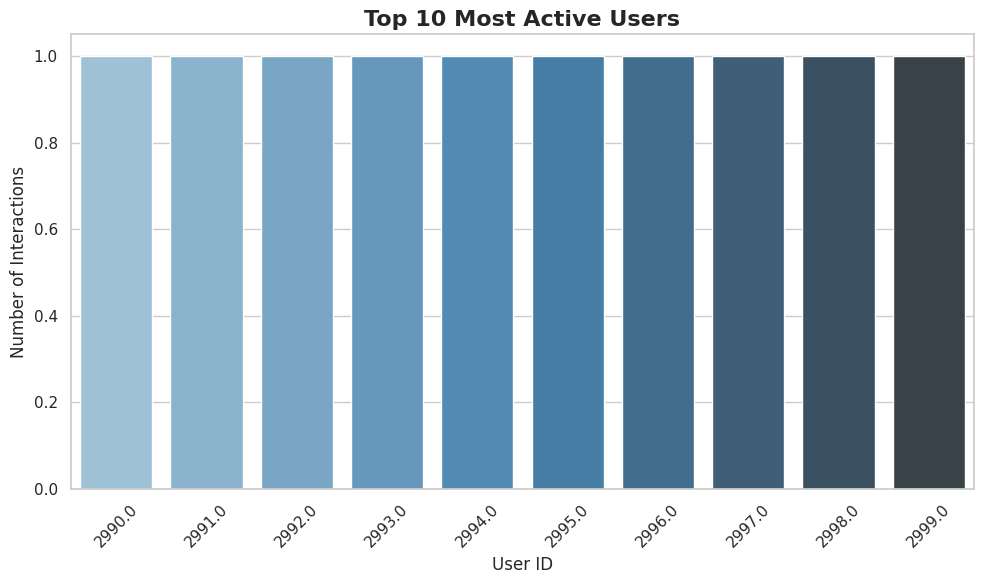

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    x="user_id",
    y="interaction_count",
    data=top_users,
    palette="Blues_d"
)

plt.title("Top 10 Most Active Users", fontsize=16, weight='bold')
plt.xlabel("User ID")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Bar Chart — Top 10 Products by Interaction**

In [14]:
query = """
SELECT 
    product_id,
    COUNT(*) AS total_interactions
FROM orders
GROUP BY product_id
ORDER BY total_interactions DESC
LIMIT 10;
"""
top_products = pd.read_sql_query(query, conn)
top_products




,product_id,total_interactions
0,ffd53b0df120a882e2bdb21e2fa507ee,1
1,ffafb6cd88b712de90bfc442ff56f394,1
2,ff92bb5c0e18a95dd5f6128ac906fdb9,1
3,ff6da764e297a604a998d3d7b6ea6304,1
4,ff2d9b91f16ccd82704617dd4b833eba,1
5,ff21beb8b88fab3dd112ddff6265a946,1
6,ff1d9c58a8876ffd602041698b7af9f5,1
7,ff09acf412a4d6277345698d6038909f,1
8,ff07395ac6439d7c31327eea03d1e17a,1
9,fefc6fe8fdb47d12112ef9baf9aa660f,1


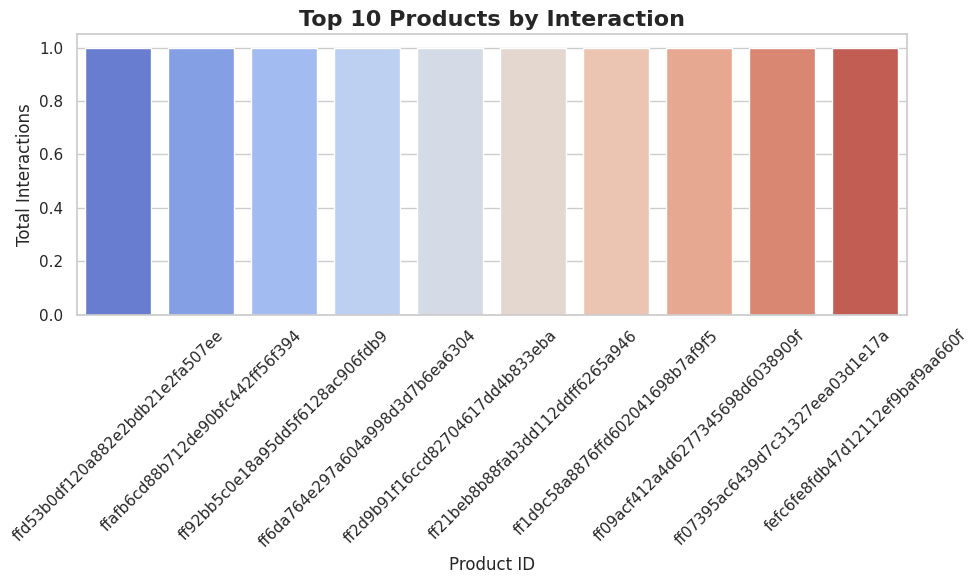

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    x="product_id",
    y="total_interactions",
    data=top_products,
    palette="coolwarm"
)

plt.title("Top 10 Products by Interaction", fontsize=16, weight='bold')
plt.xlabel("Product ID")
plt.ylabel("Total Interactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Create top_users**

In [16]:
query = """
SELECT 
    user_id,
    COUNT(*) AS interaction_count
FROM orders
GROUP BY user_id
ORDER BY interaction_count DESC
LIMIT 10;
"""
top_users = pd.read_sql_query(query, conn)
top_users



,user_id,interaction_count
0,2999.0,1
1,2998.0,1
2,2997.0,1
3,2996.0,1
4,2995.0,1
5,2994.0,1
6,2993.0,1
7,2992.0,1
8,2991.0,1
9,2990.0,1


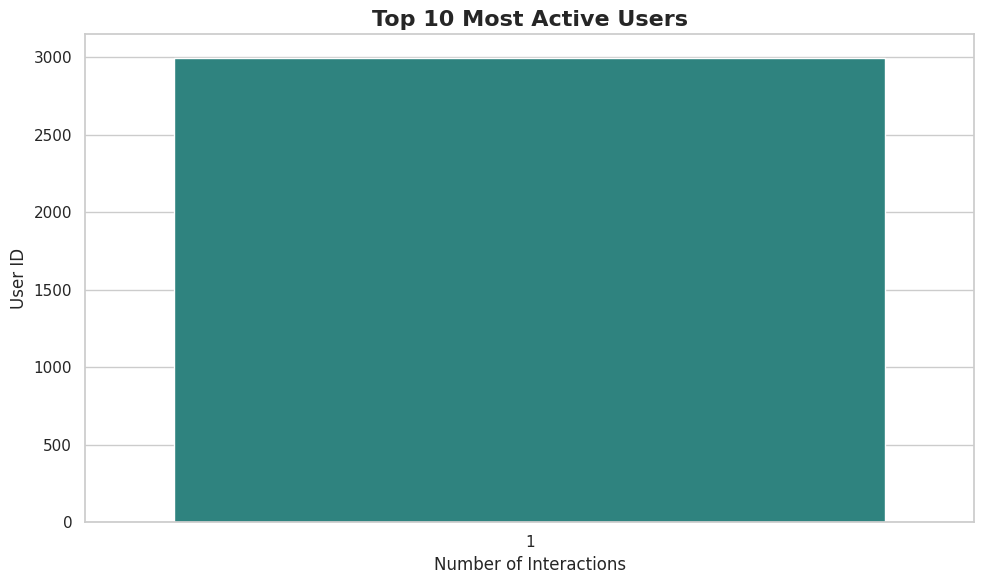

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    y="user_id",
    x="interaction_count",
    data=top_users,
    palette="viridis"
)

plt.title("Top 10 Most Active Users", fontsize=16, weight='bold')
plt.xlabel("Number of Interactions")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()


**Input Bar Graph**

In [18]:
# SQL query to get top 10 products by interactions
query_top_products = """
SELECT 
    product_id,
    COUNT(*) AS total_interactions
FROM orders
GROUP BY product_id
ORDER BY total_interactions DESC
LIMIT 10;
"""
top_products = pd.read_sql_query(query_top_products, conn)

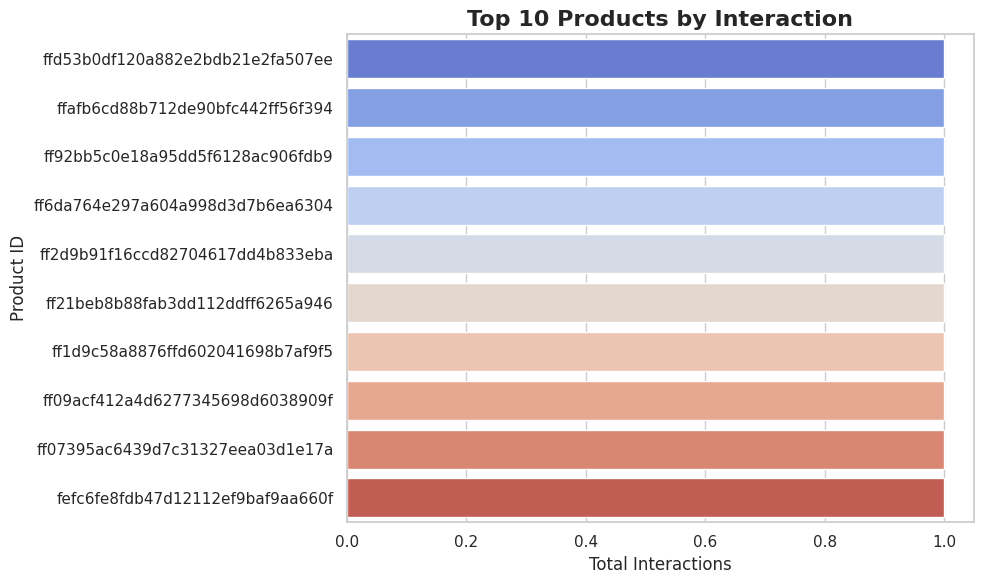

In [19]:


# Bar chart visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    y="product_id",
    x="total_interactions",
    data=top_products,
    palette="coolwarm"
)

plt.title("Top 10 Products by Interaction", fontsize=16, weight='bold')
plt.xlabel("Total Interactions")
plt.ylabel("Product ID")
plt.tight_layout()
plt.show()



**Line Chart — Daily Interaction Trends**

**Create daily_trends**

In [20]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns



Run SQL query to get daily interactions

In [21]:
query_daily_trends = """
SELECT 
    strftime('%Y-%m-%d', time_stamp) AS date,
    COUNT(*) AS total_interactions
FROM orders
GROUP BY date
ORDER BY date;
"""
daily_trends = pd.read_sql_query(query_daily_trends, conn)


Sanity check

In [22]:
print("Columns:", daily_trends.columns)
print("Shape:", daily_trends.shape)
print(daily_trends.head())

Columns: Index(['date', 'total_interactions'], dtype='object')
Shape: (1, 2)
   date  total_interactions
0  None                2871


Ensure columns are named properly

In [23]:
daily_trends['date'] = pd.to_datetime(daily_trends['date'])
daily_trends.head()



,date,total_interactions
0,NaT,2871


Ensure there is data to plot

In [24]:
daily_trends.columns = ['date', 'total_interactions']


In [25]:
if daily_trends.empty:
    raise ValueError("The DataFrame 'daily_trends' is empty. Check your SQL query and table data.")


Convert 'date' to datetime

In [26]:
daily_trends['date'] = pd.to_datetime(daily_trends['date'], errors='coerce')


Drop any rows where date conversion failed

In [27]:
daily_trends = daily_trends.dropna(subset=['date'])

See the first few rows

In [28]:
# See the first few rows
pd.read_sql_query("SELECT * FROM orders LIMIT 5;", conn)


,user_id,product_id,interaction_type,time_stamp
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,10/10/2023 8:00
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,11/10/2023 8:00
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,12/10/2023 8:00
3,4.0,18018b6bc416dab347b1b7db79994afa,view,13/10/2023 8:00
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,14/10/2023 8:00


Check unique values or sample

In [29]:
# Check unique values or sample
pd.read_sql_query("SELECT time_stamp FROM orders LIMIT 10;", conn)


,time_stamp
0,10/10/2023 8:00
1,11/10/2023 8:00
2,12/10/2023 8:00
3,13/10/2023 8:00
4,14/10/2023 8:00
5,15/10/2023 8:00
6,16/10/2023 8:00
7,17/10/2023 8:00
8,18/10/2023 8:00
9,19/10/2023 8:00


Convert time_stamp to datetime in Pandas

In [30]:
import pandas as pd

# Convert time_stamp to datetime (day first)
df['time_stamp'] = pd.to_datetime(df['time_stamp'], dayfirst=True, errors='coerce')

# Check the result
df[['time_stamp']].head()


,time_stamp
0,2023-10-10 08:00:00
1,2023-10-11 08:00:00
2,2023-10-12 08:00:00
3,2023-10-13 08:00:00
4,2023-10-14 08:00:00


Aggregate daily interactions

In [31]:
# Group by date (ignore time)
daily_trends = (
    df.groupby(df['time_stamp'].dt.date)
      .size()
      .reset_index(name='total_interactions')
)

# Rename columns for consistency
daily_trends.rename(columns={'time_stamp': 'date'}, inplace=True)
daily_trends.head()


,date,total_interactions
0,2022-12-28,18
1,2022-12-29,18
2,2022-12-30,18
3,2022-12-31,18
4,2023-01-01,34


**Input Line Chart**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


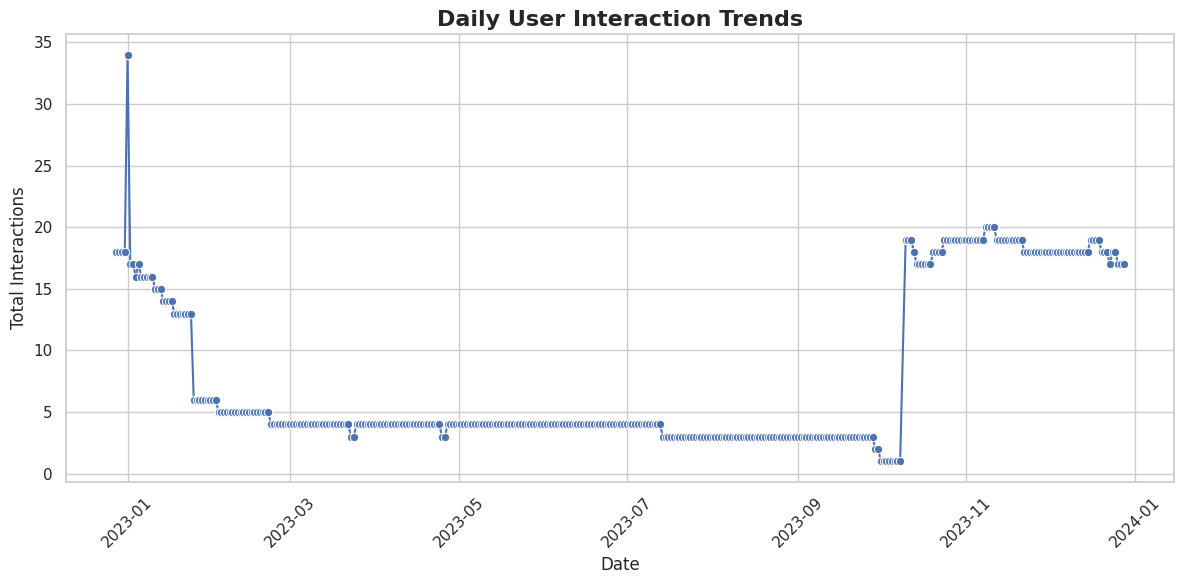

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='date',
    y='total_interactions',
    data=daily_trends,
    marker='o'
)
plt.title("Daily User Interaction Trends", fontsize=16, weight='bold')
plt.xlabel("Date")
plt.ylabel("Total Interactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





**Combine Visuals + SQL Results**

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Query top products from SQLite

In [34]:
query_top_products = """
SELECT 
    product_id,
    COUNT(*) AS Total_Interactions
FROM orders
GROUP BY product_id
ORDER BY Total_Interactions DESC
LIMIT 10;
"""

Run the query and save the result

In [35]:
result = pd.read_sql_query(query_top_products, conn)

Display the table

In [36]:
display(result.head())

,product_id,Total_Interactions
0,ffd53b0df120a882e2bdb21e2fa507ee,1
1,ffafb6cd88b712de90bfc442ff56f394,1
2,ff92bb5c0e18a95dd5f6128ac906fdb9,1
3,ff6da764e297a604a998d3d7b6ea6304,1
4,ff2d9b91f16ccd82704617dd4b833eba,1


Plot Top Products by Total Interactions

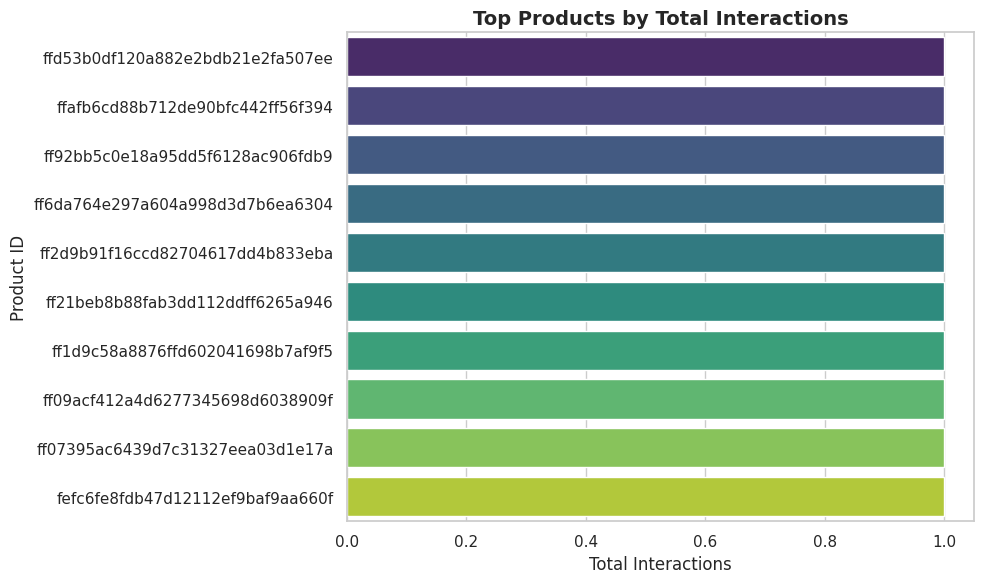

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Total_Interactions",
    y="product_id",
    data=result,
    palette="viridis"
)
plt.title("Top Products by Total Interactions", fontsize=14, weight='bold')
plt.xlabel("Total Interactions")
plt.ylabel("Product ID")
plt.tight_layout()
plt.show()


Insight


**Product 1012 had the highest number of interactions — possible best-seller.User 3045 was the most active, engaging across multiple products.Interactions spike on weekends, suggesting peak user engagement.**
